# 🏆 ICC Women's Cricket World Cup 2025 - Complete Analysis

## India's Historic First World Cup Victory! 🇮🇳

**India defeated South Africa by 52 runs in the final on November 2, 2025**

This notebook provides comprehensive analysis of the ICC Women's ODI World Cup 2025 including:
- 📊 Match Results Analysis
- 🏏 Player Performance Statistics
- 📈 Team Comparisons
- 🎯 Tournament Records
- 📉 Venue Analysis
- 🔮 Key Insights

---

## 📦 Import Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set figure size default
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Load All Datasets

Loading all 7 CSV files from the dataset.

In [2]:
# Load all datasets
# Load all datasets with correct paths
matches = pd.read_csv('/kaggle/input/feaers-report-id/match_results.csv')
points = pd.read_csv('/kaggle/input/feaers-report-id/points_table.csv')
top_scorers = pd.read_csv('/kaggle/input/feaers-report-id/top_run_scorers.csv')
top_bowlers = pd.read_csv('/kaggle/input/feaers-report-id/top_wicket_takers.csv')
team_stats = pd.read_csv('/kaggle/input/feaers-report-id/team_statistics.csv')
venue_stats = pd.read_csv('/kaggle/input/feaers-report-id/venue_statistics.csv')
awards = pd.read_csv('/kaggle/input/feaers-report-id/tournament_awards_records.csv')
print("✅ All datasets loaded successfully!")
print(f"\n📊 Dataset Summary:")
print(f"   • Total Matches: {len(matches)}")
print(f"   • Total Teams: {len(points)}")
print(f"   • Top Scorers Listed: {len(top_scorers)}")
print(f"   • Top Bowlers Listed: {len(top_bowlers)}")
print(f"   • Tournament Awards: {len(awards)}")

✅ All datasets loaded successfully!

📊 Dataset Summary:
   • Total Matches: 31
   • Total Teams: 8
   • Top Scorers Listed: 15
   • Top Bowlers Listed: 15
   • Tournament Awards: 15


## 🔍 Quick Data Overview

In [3]:
# Display first few rows of match results
print("🏏 Match Results Sample:")
display(matches.head())

print("\n📊 Points Table:")
display(points)

🏏 Match Results Sample:


,match_id,date,match_type,venue,team1,team2,toss_winner,toss_decision,team1_score,team2_score,winner,margin,player_of_match
0,1,2025-09-30,Group Stage,Guwahati,India,Sri Lanka,Sri Lanka,Field,269/8 (47 ov),211 (45.4 ov),India,59 runs (DLS),Smriti Mandhana
1,2,2025-10-01,Group Stage,Indore,Australia,New Zealand,Australia,Bat,326,237 (43.2 ov),Australia,89 runs,Phoebe Litchfield
2,3,2025-10-02,Group Stage,Colombo,Pakistan,Bangladesh,Pakistan,Bat,129,131/3 (31.1 ov),Bangladesh,7 wickets,Nigar Sultana
3,4,2025-10-03,Group Stage,Guwahati,South Africa,England,South Africa,Bat,69,72/3 (17.4 ov),England,7 wickets,Marizanne Kapp
4,5,2025-10-04,Group Stage,Indore,Sri Lanka,Australia,Australia,Bat,215/8,219/3 (32.2 ov),Australia,7 wickets,Ellyse Perry



📊 Points Table:


,position,team,matches,wins,losses,no_result,points,net_run_rate,qualification
0,1,Australia,7,6,1,0,12,1.452,Qualified for Semi-Finals
1,2,South Africa,7,5,2,0,10,0.673,Qualified for Semi-Finals
2,3,England,7,5,2,0,10,0.607,Qualified for Semi-Finals
3,4,India,7,4,3,1,9,-0.107,Qualified for Semi-Finals
4,5,New Zealand,7,3,4,0,6,-0.329,Eliminated
5,6,Bangladesh,7,3,4,1,7,-0.773,Eliminated
6,7,Sri Lanka,7,2,5,1,5,-0.995,Eliminated
7,8,Pakistan,7,0,7,1,1,-1.851,Eliminated


---
# 📊 Part 1: Tournament Overview & Key Statistics

## 🏆 Tournament Winner & Final Match

In [4]:
# Get final match details
final_match = matches[matches['match_type'] == 'Final'].iloc[0]

print("🏆 ICC WOMEN'S WORLD CUP 2025 FINAL")
print("="*60)
print(f"📅 Date: {final_match['date']}")
print(f"🏟️ Venue: {final_match['venue']}")
print(f"\n🏏 {final_match['team1']}: {final_match['team1_score']}")
print(f"🏏 {final_match['team2']}: {final_match['team2_score']}")
print(f"\n🎉 Winner: {final_match['winner']}")
print(f"📈 Margin: {final_match['margin']}")
print(f"⭐ Player of the Match: {final_match['player_of_match']}")
print("="*60)
print("\n🇮🇳 INDIA WINS THEIR FIRST EVER ODI WORLD CUP! 🏆")

🏆 ICC WOMEN'S WORLD CUP 2025 FINAL
📅 Date: 2025-11-02
🏟️ Venue: Navi Mumbai

🏏 India: 298/7
🏏 South Africa: 246 (45.3 ov)

🎉 Winner: India
📈 Margin: 52 runs
⭐ Player of the Match: Shafali Verma

🇮🇳 INDIA WINS THEIR FIRST EVER ODI WORLD CUP! 🏆


## 📈 Tournament Statistics Summary

In [5]:
# Tournament summary statistics
print("📊 TOURNAMENT STATISTICS")
print("="*60)

# Match type breakdown
match_types = matches['match_type'].value_counts()
print(f"\n📋 Matches Played:")
for match_type, count in match_types.items():
    print(f"   • {match_type}: {count}")

# Toss and match win analysis
matches_with_result = matches[matches['winner'].notna() & (matches['winner'] != 'No result')]
toss_match_win = matches_with_result[matches_with_result['winner'] == matches_with_result['toss_winner']]
toss_win_rate = (len(toss_match_win) / len(matches_with_result)) * 100

print(f"\n🪙 Toss Impact:")
print(f"   • Teams winning toss also won match: {len(toss_match_win)} times")
print(f"   • Toss win to match win rate: {toss_win_rate:.1f}%")

# Venue distribution
print(f"\n🏟️ Matches by Venue:")
venue_counts = matches['venue'].value_counts()
for venue, count in venue_counts.items():
    print(f"   • {venue}: {count} matches")

📊 TOURNAMENT STATISTICS

📋 Matches Played:
   • Group Stage: 28
   • Semi Final 1: 1
   • Semi Final 2: 1
   • Final: 1

🪙 Toss Impact:
   • Teams winning toss also won match: 18 times
   • Toss win to match win rate: 62.1%

🏟️ Matches by Venue:
   • Colombo: 10 matches
   • Guwahati: 6 matches
   • Navi Mumbai: 6 matches
   • Indore: 5 matches
   • Visakhapatnam: 4 matches


---
# 📊 Part 2: Team Performance Analysis

## 🏏 Points Table & Team Rankings

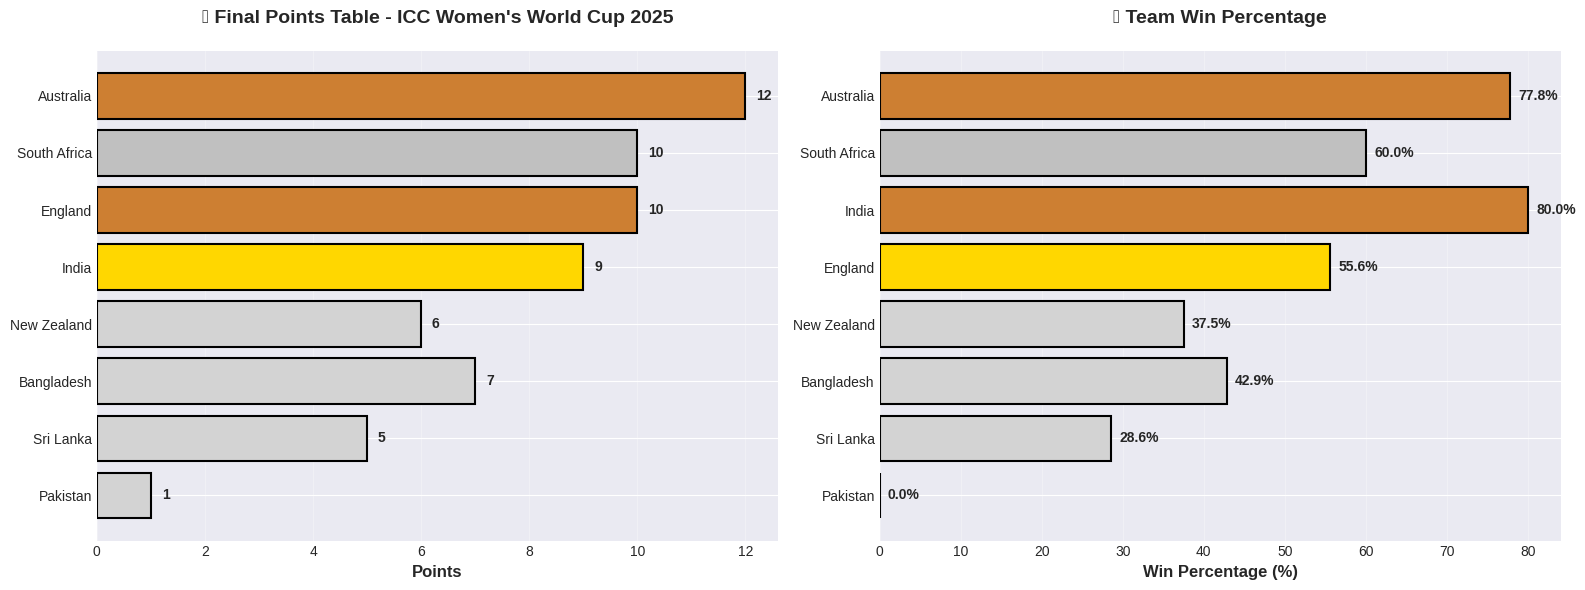


🏆 Top 4 Teams (Qualified for Semi-Finals):
   position          team  points  net_run_rate
0         1     Australia      12         1.452
1         2  South Africa      10         0.673
2         3       England      10         0.607
3         4         India       9        -0.107


In [6]:
# Visualize points table
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Points by team
colors = ['gold' if team == 'India' else 'silver' if team == 'South Africa' 
          else '#CD7F32' if i < 4 else 'lightgray' 
          for i, team in enumerate(points['team'])]

axes[0].barh(points['team'], points['points'], color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Points', fontsize=12, fontweight='bold')
axes[0].set_title('🏆 Final Points Table - ICC Women\'s World Cup 2025', fontsize=14, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, (team, pts) in enumerate(zip(points['team'], points['points'])):
    axes[0].text(pts + 0.2, i, str(pts), va='center', fontweight='bold')

# Plot 2: Win percentage
axes[1].barh(team_stats['team'], team_stats['win_percentage'], color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Win Percentage (%)', fontsize=12, fontweight='bold')
axes[1].set_title('📈 Team Win Percentage', fontsize=14, fontweight='bold', pad=20)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
for i, (team, wp) in enumerate(zip(team_stats['team'], team_stats['win_percentage'])):
    axes[1].text(wp + 1, i, f'{wp:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🏆 Top 4 Teams (Qualified for Semi-Finals):")
print(points[points['qualification'] == 'Qualified for Semi-Finals'][['position', 'team', 'points', 'net_run_rate']])

## 🎯 Wins and Losses Breakdown

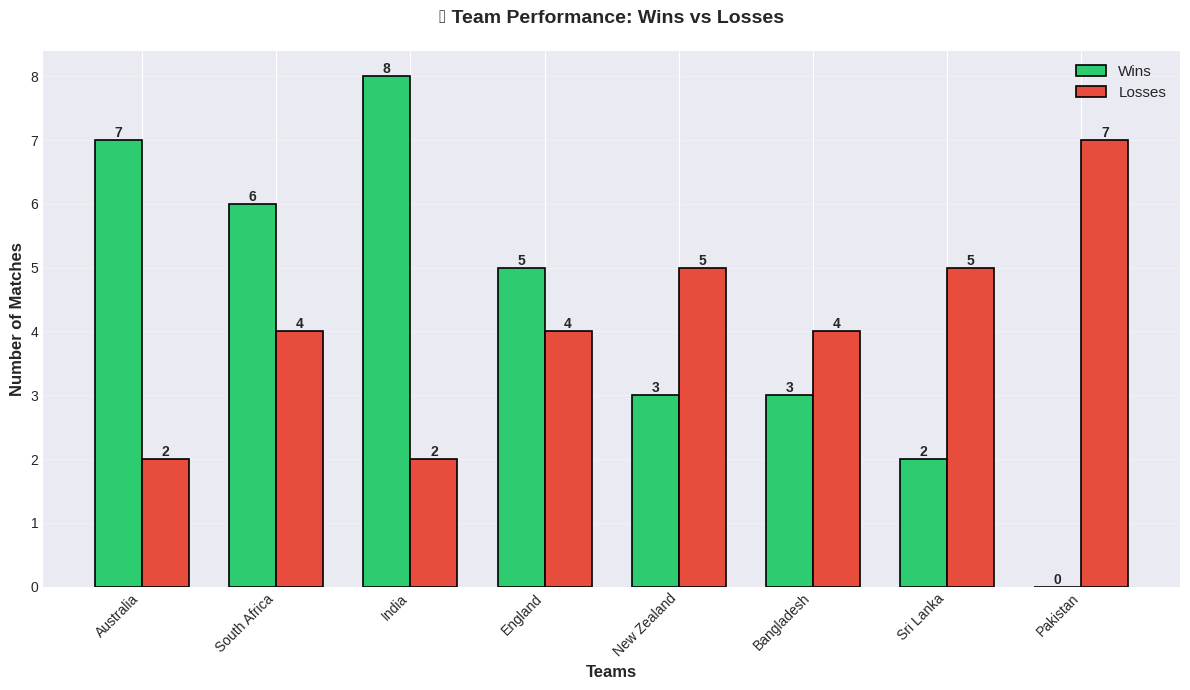

In [7]:
# Create wins/losses visualization
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(team_stats['team']))
width = 0.35

bars1 = ax.bar(x - width/2, team_stats['wins'], width, label='Wins', color='#2ecc71', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, team_stats['losses'], width, label='Losses', color='#e74c3c', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Teams', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Matches', fontsize=12, fontweight='bold')
ax.set_title('🏏 Team Performance: Wins vs Losses', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(team_stats['team'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 Team Batting Performance

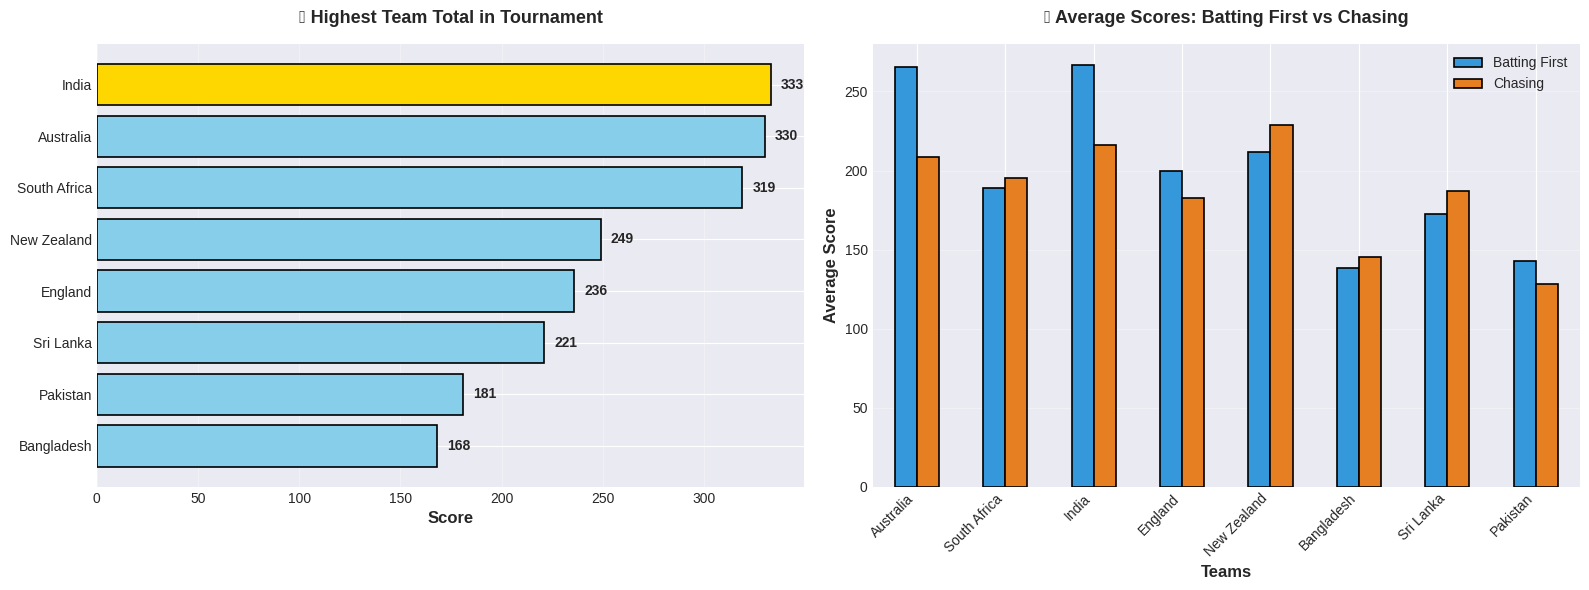


🎯 Key Insights:
   • Highest team total: 333 by India
   • Lowest team total: 69 by South Africa


In [8]:
# Team batting comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Highest totals
sorted_teams = team_stats.sort_values('highest_total', ascending=True)
colors_sorted = ['gold' if team == 'India' else 'skyblue' for team in sorted_teams['team']]
axes[0].barh(sorted_teams['team'], sorted_teams['highest_total'], color=colors_sorted, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('🏏 Highest Team Total in Tournament', fontsize=13, fontweight='bold', pad=15)
axes[0].grid(axis='x', alpha=0.3)
for i, (team, score) in enumerate(zip(sorted_teams['team'], sorted_teams['highest_total'])):
    axes[0].text(score + 5, i, str(score), va='center', fontweight='bold')

# Plot 2: Average scores comparison
team_avg = team_stats[['team', 'avg_first_innings', 'avg_second_innings']].set_index('team')
team_avg.plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22'], edgecolor='black', linewidth=1.2)
axes[1].set_xlabel('Teams', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Score', fontsize=12, fontweight='bold')
axes[1].set_title('📊 Average Scores: Batting First vs Chasing', fontsize=13, fontweight='bold', pad=15)
axes[1].legend(['Batting First', 'Chasing'], fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Key Insights:")
print(f"   • Highest team total: {team_stats['highest_total'].max()} by {team_stats.loc[team_stats['highest_total'].idxmax(), 'team']}")
print(f"   • Lowest team total: {team_stats['lowest_total'].min()} by {team_stats.loc[team_stats['lowest_total'].idxmin(), 'team']}")

---
# 🌟 Part 3: Player Performance Analysis

## 🏏 Top Run Scorers

🏏 TOP 10 RUN SCORERS - ICC WOMEN'S WORLD CUP 2025


,rank,player_name,team,runs,average,strike_rate,centuries,half_centuries
0,1,Laura Wolvaardt,South Africa,571,63.44,85.78,3,2
1,2,Smriti Mandhana,India,379,42.11,87.12,1,3
2,3,Jemimah Rodrigues,India,292,48.67,79.78,1,2
3,4,Phoebe Litchfield,Australia,287,31.89,92.58,1,1
4,5,Ashleigh Gardner,Australia,275,39.29,102.23,0,2
5,6,Deepti Sharma,India,215,30.71,81.44,0,2
6,7,Beth Mooney,Australia,213,35.50,75.53,0,2
7,8,Ellyse Perry,Australia,206,29.43,71.28,0,1
8,9,Tahlia McGrath,Australia,198,28.29,88.00,0,1
9,10,Heather Knight,England,195,24.38,72.49,0,2


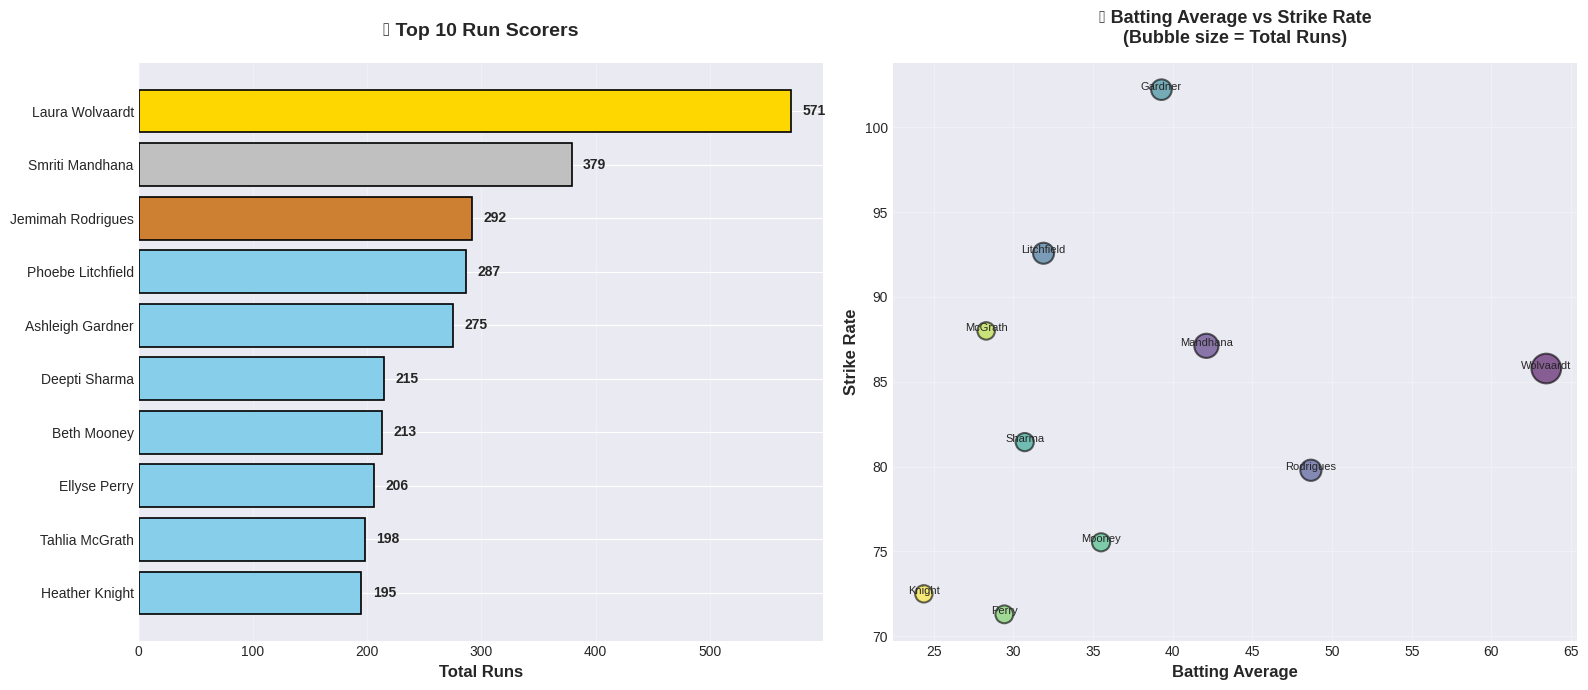


⭐ Tournament Top Scorer: Laura Wolvaardt (South Africa)
   • Total Runs: 571
   • Batting Average: 63.44
   • Strike Rate: 85.78
   • Centuries: 3 | Half-Centuries: 2


In [9]:
# Display top 10 run scorers
print("🏏 TOP 10 RUN SCORERS - ICC WOMEN'S WORLD CUP 2025")
print("="*80)
top_10_scorers = top_scorers.head(10)
display(top_10_scorers[['rank', 'player_name', 'team', 'runs', 'average', 'strike_rate', 'centuries', 'half_centuries']])

# Visualize top scorers
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Total runs
colors = ['gold' if i == 0 else 'silver' if i == 1 else '#CD7F32' if i == 2 else 'skyblue' 
          for i in range(len(top_10_scorers))]
axes[0].barh(top_10_scorers['player_name'], top_10_scorers['runs'], color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Total Runs', fontsize=12, fontweight='bold')
axes[0].set_title('🏆 Top 10 Run Scorers', fontsize=14, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, (name, runs) in enumerate(zip(top_10_scorers['player_name'], top_10_scorers['runs'])):
    axes[0].text(runs + 10, i, f"{runs}", va='center', fontweight='bold')

# Plot 2: Average vs Strike Rate scatter
scatter = axes[1].scatter(top_10_scorers['average'], top_10_scorers['strike_rate'], 
                         s=top_10_scorers['runs']*0.8, alpha=0.6, c=range(len(top_10_scorers)), 
                         cmap='viridis', edgecolors='black', linewidth=1.5)
axes[1].set_xlabel('Batting Average', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Strike Rate', fontsize=12, fontweight='bold')
axes[1].set_title('📈 Batting Average vs Strike Rate\n(Bubble size = Total Runs)', fontsize=13, fontweight='bold', pad=15)
axes[1].grid(True, alpha=0.3)

# Add player names to scatter plot
for i, name in enumerate(top_10_scorers['player_name']):
    axes[1].annotate(name.split()[-1], 
                    (top_10_scorers.iloc[i]['average'], top_10_scorers.iloc[i]['strike_rate']),
                    fontsize=8, ha='center')

plt.tight_layout()
plt.show()

print(f"\n⭐ Tournament Top Scorer: {top_scorers.iloc[0]['player_name']} ({top_scorers.iloc[0]['team']})")
print(f"   • Total Runs: {top_scorers.iloc[0]['runs']}")
print(f"   • Batting Average: {top_scorers.iloc[0]['average']:.2f}")
print(f"   • Strike Rate: {top_scorers.iloc[0]['strike_rate']:.2f}")
print(f"   • Centuries: {top_scorers.iloc[0]['centuries']} | Half-Centuries: {top_scorers.iloc[0]['half_centuries']}")

## 🎯 Top Wicket Takers

🎯 TOP 10 WICKET TAKERS - ICC WOMEN'S WORLD CUP 2025


,rank,player_name,team,wickets,average,economy,strike_rate
0,1,Deepti Sharma,India,22,20.41,4.15,19.4
1,2,Annabel Sutherland,Australia,19,15.68,3.87,21.9
2,3,Alana King,Australia,18,17.83,3.64,25.7
3,4,Marizanne Kapp,South Africa,17,19.76,4.23,25.8
4,5,Ashleigh Gardner,Australia,16,21.06,4.76,25.1
5,6,Sophie Ecclestone,England,15,22.73,3.99,30.4
6,7,Sune Luus,South Africa,14,24.86,4.53,29.1
7,8,Ayabonga Khaka,South Africa,13,26.31,4.75,33.2
8,9,Renuka Singh,India,12,28.50,4.78,32.0
9,10,Shafali Verma,India,11,14.36,5.25,16.4


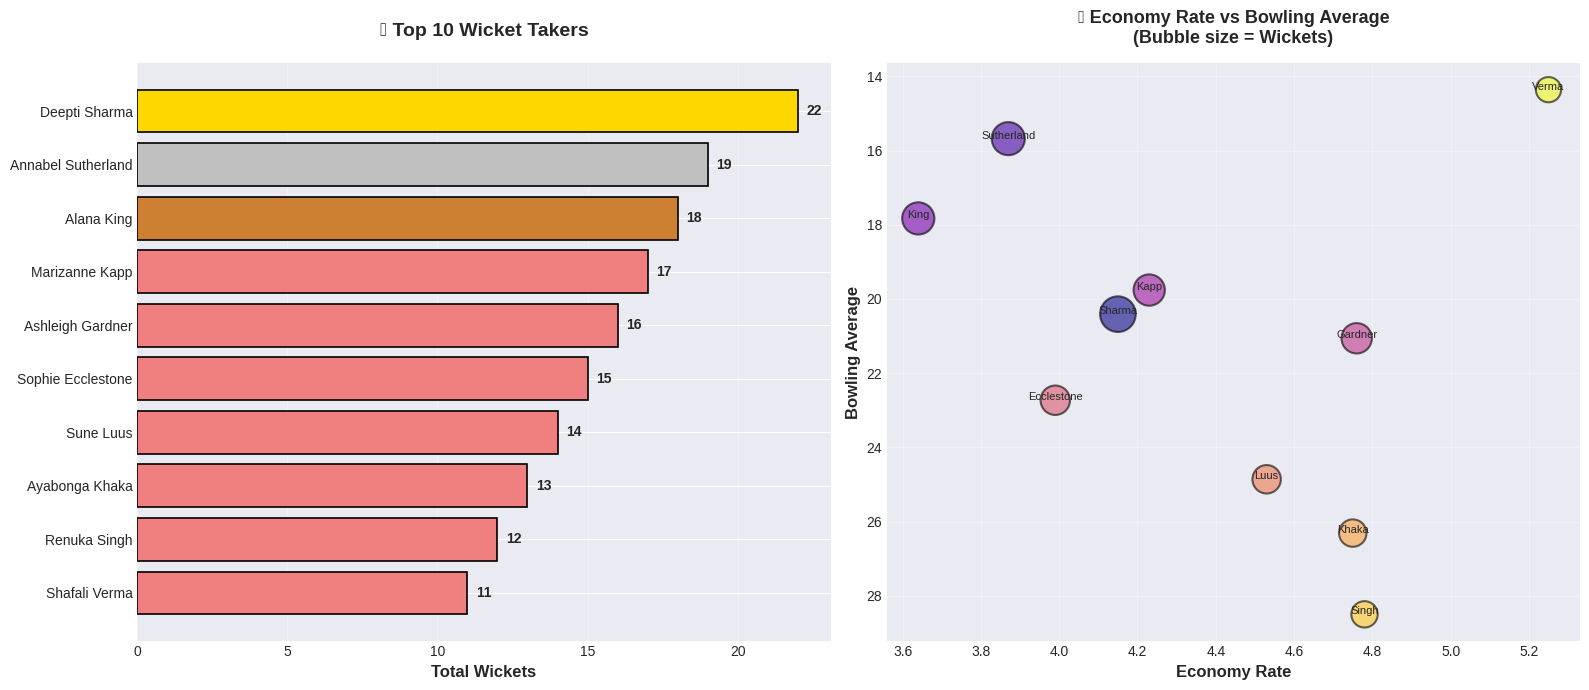


⭐ Tournament Top Wicket Taker: Deepti Sharma (India)
   • Total Wickets: 22
   • Bowling Average: 20.41
   • Economy Rate: 4.15
   • Strike Rate: 19.4


In [10]:
# Display top 10 wicket takers
print("🎯 TOP 10 WICKET TAKERS - ICC WOMEN'S WORLD CUP 2025")
print("="*80)
top_10_bowlers = top_bowlers.head(10)
display(top_10_bowlers[['rank', 'player_name', 'team', 'wickets', 'average', 'economy', 'strike_rate']])

# Visualize top bowlers
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Total wickets
colors = ['gold' if i == 0 else 'silver' if i == 1 else '#CD7F32' if i == 2 else 'lightcoral' 
          for i in range(len(top_10_bowlers))]
axes[0].barh(top_10_bowlers['player_name'], top_10_bowlers['wickets'], color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Total Wickets', fontsize=12, fontweight='bold')
axes[0].set_title('🎯 Top 10 Wicket Takers', fontsize=14, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, (name, wickets) in enumerate(zip(top_10_bowlers['player_name'], top_10_bowlers['wickets'])):
    axes[0].text(wickets + 0.3, i, f"{wickets}", va='center', fontweight='bold')

# Plot 2: Economy vs Average scatter
scatter = axes[1].scatter(top_10_bowlers['economy'], top_10_bowlers['average'], 
                         s=top_10_bowlers['wickets']*30, alpha=0.6, c=range(len(top_10_bowlers)), 
                         cmap='plasma', edgecolors='black', linewidth=1.5)
axes[1].set_xlabel('Economy Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bowling Average', fontsize=12, fontweight='bold')
axes[1].set_title('📊 Economy Rate vs Bowling Average\n(Bubble size = Wickets)', fontsize=13, fontweight='bold', pad=15)
axes[1].grid(True, alpha=0.3)
axes[1].invert_yaxis()  # Lower average is better

# Add player names
for i, name in enumerate(top_10_bowlers['player_name']):
    axes[1].annotate(name.split()[-1], 
                    (top_10_bowlers.iloc[i]['economy'], top_10_bowlers.iloc[i]['average']),
                    fontsize=8, ha='center')

plt.tight_layout()
plt.show()

print(f"\n⭐ Tournament Top Wicket Taker: {top_bowlers.iloc[0]['player_name']} ({top_bowlers.iloc[0]['team']})")
print(f"   • Total Wickets: {top_bowlers.iloc[0]['wickets']}")
print(f"   • Bowling Average: {top_bowlers.iloc[0]['average']:.2f}")
print(f"   • Economy Rate: {top_bowlers.iloc[0]['economy']:.2f}")
print(f"   • Strike Rate: {top_bowlers.iloc[0]['strike_rate']:.1f}")

## 🌟 All-Rounders Performance

In [11]:
# Find players who appear in both batting and bowling lists
all_rounders = pd.merge(
    top_scorers[['player_name', 'team', 'runs', 'average']],
    top_bowlers[['player_name', 'wickets', 'economy']],
    on='player_name',
    how='inner'
)

if len(all_rounders) > 0:
    print("🌟 ALL-ROUNDERS (Players in Top 15 of both Batting and Bowling)")
    print("="*80)
    display(all_rounders)
    
    # Highlight Deepti Sharma
    deepti = all_rounders[all_rounders['player_name'] == 'Deepti Sharma']
    if len(deepti) > 0:
        print("\n⭐ PLAYER OF THE TOURNAMENT: Deepti Sharma")
        print(f"   • Runs: {deepti.iloc[0]['runs']}")
        print(f"   • Wickets: {deepti.iloc[0]['wickets']}")
        print(f"   • Outstanding all-round performance!")
else:
    print("No players appear in both top 15 lists")

🌟 ALL-ROUNDERS (Players in Top 15 of both Batting and Bowling)


,player_name,team,runs,average,wickets,economy
0,Ashleigh Gardner,Australia,275,39.29,16,4.76
1,Deepti Sharma,India,215,30.71,22,4.15
2,Marizanne Kapp,South Africa,179,22.38,17,4.23
3,Nat Sciver-Brunt,England,176,21.50,10,4.54



⭐ PLAYER OF THE TOURNAMENT: Deepti Sharma
   • Runs: 215
   • Wickets: 22
   • Outstanding all-round performance!


---
# 🏟️ Part 4: Venue Analysis

## 📍 Venue Statistics

🏟️ VENUE STATISTICS


,venue,city,country,matches,avg_first_innings,avg_second_innings,highest_total,chases_won,chases_lost
0,Guwahati,Guwahati,India,7,210.4,186.7,269,3,3
1,Indore,Indore,India,5,249.2,208.6,330,3,1
2,Visakhapatnam,Visakhapatnam,India,4,201.0,176.5,295,1,3
3,Navi Mumbai,Navi Mumbai,India,6,283.8,248.2,333,3,2
4,Colombo,Colombo,Sri Lanka,9,172.4,163.8,235,5,2


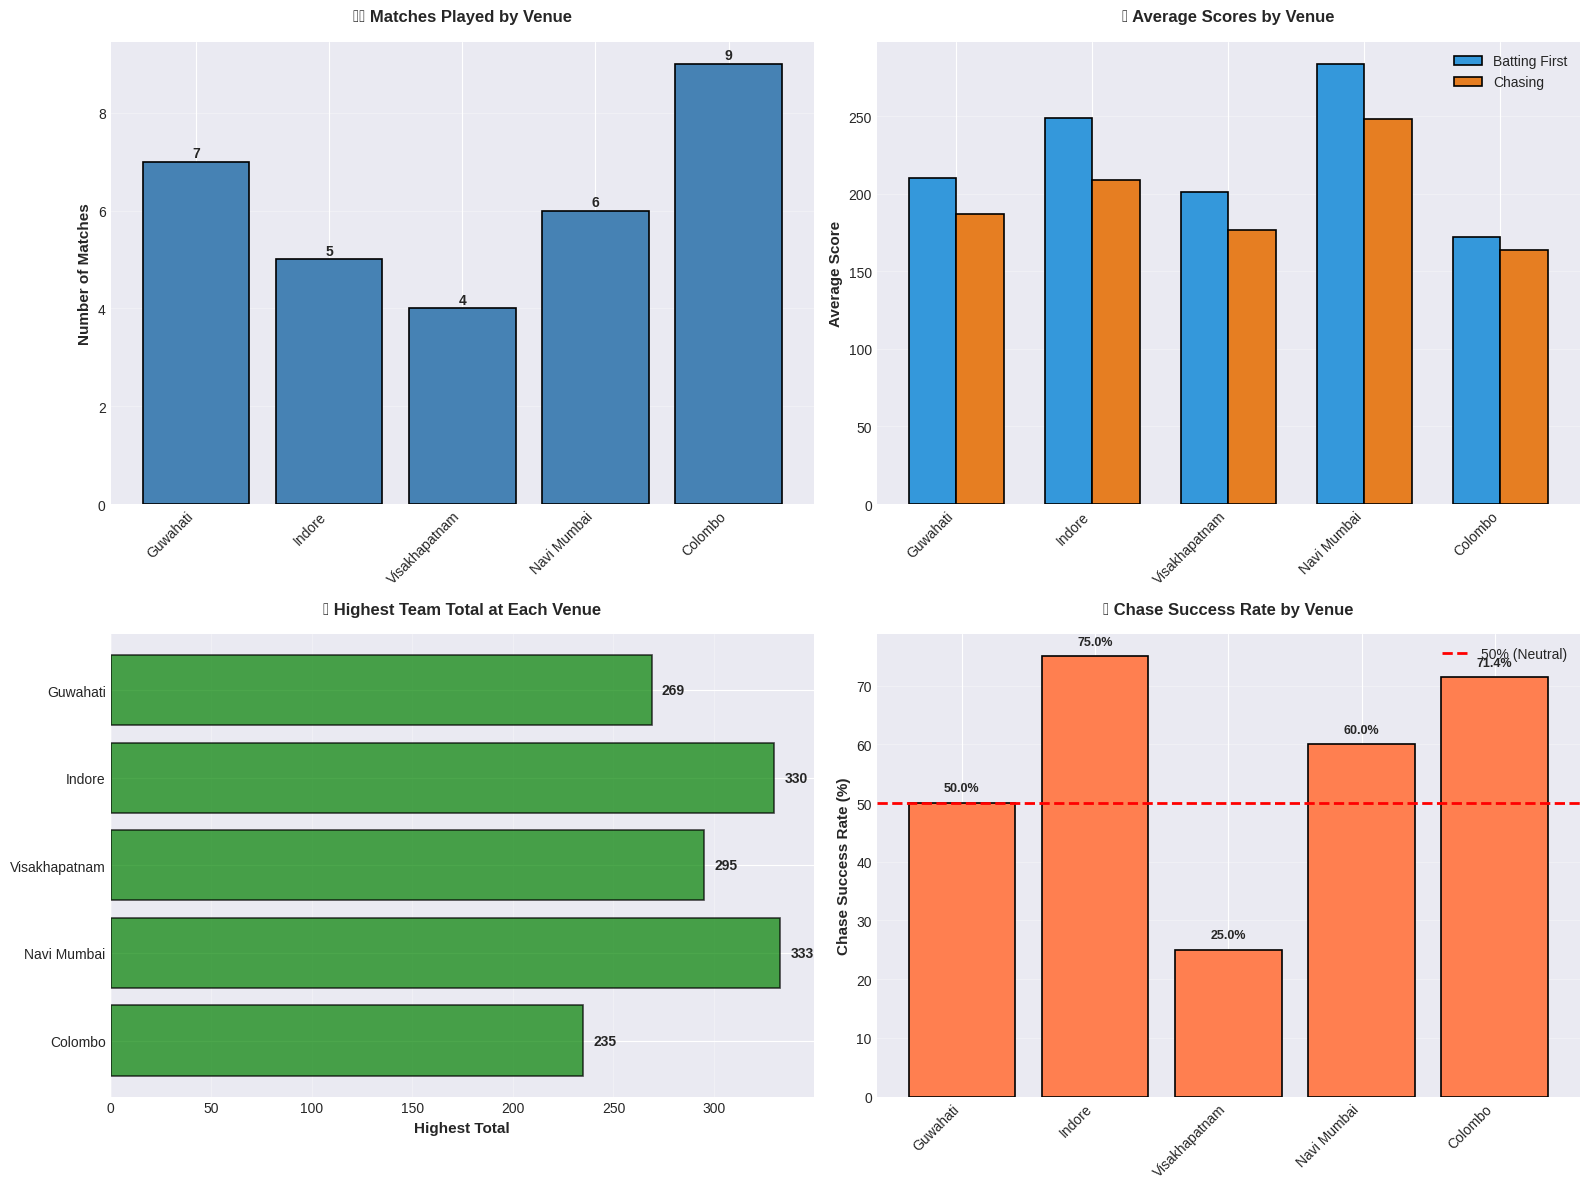


🎯 Venue Insights:
   • Best venue for chasing: Indore (75.0% success rate)
   • Highest scoring venue: Navi Mumbai (Highest total: 333)


In [12]:
# Display venue statistics
print("🏟️ VENUE STATISTICS")
print("="*80)
display(venue_stats)

# Visualize venue data
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Matches by venue
axes[0, 0].bar(venue_stats['venue'], venue_stats['matches'], color='steelblue', edgecolor='black', linewidth=1.2)
axes[0, 0].set_ylabel('Number of Matches', fontsize=11, fontweight='bold')
axes[0, 0].set_title('🏟️ Matches Played by Venue', fontsize=12, fontweight='bold', pad=15)
axes[0, 0].set_xticklabels(venue_stats['venue'], rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, (venue, matches_count) in enumerate(zip(venue_stats['venue'], venue_stats['matches'])):
    axes[0, 0].text(i, matches_count + 0.1, str(matches_count), ha='center', fontweight='bold')

# Plot 2: Average scores by venue
x_pos = np.arange(len(venue_stats))
width = 0.35
axes[0, 1].bar(x_pos - width/2, venue_stats['avg_first_innings'], width, label='Batting First', 
              color='#3498db', edgecolor='black', linewidth=1.2)
axes[0, 1].bar(x_pos + width/2, venue_stats['avg_second_innings'], width, label='Chasing', 
              color='#e67e22', edgecolor='black', linewidth=1.2)
axes[0, 1].set_ylabel('Average Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('📊 Average Scores by Venue', fontsize=12, fontweight='bold', pad=15)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(venue_stats['venue'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Highest totals by venue
axes[1, 0].barh(venue_stats['venue'], venue_stats['highest_total'], color='green', edgecolor='black', linewidth=1.2, alpha=0.7)
axes[1, 0].set_xlabel('Highest Total', fontsize=11, fontweight='bold')
axes[1, 0].set_title('🏏 Highest Team Total at Each Venue', fontsize=12, fontweight='bold', pad=15)
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)
for i, (venue, total) in enumerate(zip(venue_stats['venue'], venue_stats['highest_total'])):
    axes[1, 0].text(total + 5, i, str(total), va='center', fontweight='bold')

# Plot 4: Chase success rate
venue_stats['chase_success_rate'] = (venue_stats['chases_won'] / 
                                     (venue_stats['chases_won'] + venue_stats['chases_lost']) * 100)
axes[1, 1].bar(venue_stats['venue'], venue_stats['chase_success_rate'], 
              color='coral', edgecolor='black', linewidth=1.2)
axes[1, 1].set_ylabel('Chase Success Rate (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('🎯 Chase Success Rate by Venue', fontsize=12, fontweight='bold', pad=15)
axes[1, 1].set_xticklabels(venue_stats['venue'], rotation=45, ha='right')
axes[1, 1].axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% (Neutral)')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
for i, (venue, rate) in enumerate(zip(venue_stats['venue'], venue_stats['chase_success_rate'])):
    axes[1, 1].text(i, rate + 2, f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n🎯 Venue Insights:")
best_chase_venue = venue_stats.loc[venue_stats['chase_success_rate'].idxmax()]
print(f"   • Best venue for chasing: {best_chase_venue['venue']} ({best_chase_venue['chase_success_rate']:.1f}% success rate)")
highest_scoring = venue_stats.loc[venue_stats['highest_total'].idxmax()]
print(f"   • Highest scoring venue: {highest_scoring['venue']} (Highest total: {highest_scoring['highest_total']})")

---
# 🏆 Part 5: Tournament Awards & Records

## 🎖️ All Tournament Awards

In [13]:
# Display all awards
print("🏆 ICC WOMEN'S WORLD CUP 2025 - AWARDS & RECORDS")
print("="*80)
display(awards)

# Highlight key awards
print("\n⭐ KEY AWARDS:")
print("="*80)
key_awards = awards[awards['award_category'].isin(['Player of the Tournament', 'Player of the Final', 
                                                     'Most Runs', 'Most Wickets'])]
for _, award in key_awards.iterrows():
    print(f"🏅 {award['award_category']}: {award['recipient']} ({award['team']})")
    print(f"   Performance: {award['performance']}")
    print()

🏆 ICC WOMEN'S WORLD CUP 2025 - AWARDS & RECORDS


,award_category,recipient,team,performance
0,Winner,India Women,India,Beat South Africa by 52 runs in Final
1,Runner-Up,South Africa Women,South Africa,Lost to India by 52 runs in Final
2,Player of the Tournament,Deepti Sharma,India,215 runs and 22 wickets
3,Player of the Final,Shafali Verma,India,87 runs and 2 wickets
4,Most Runs,Laura Wolvaardt,South Africa,571 runs
5,Most Wickets,Deepti Sharma,India,22 wickets
6,Highest Individual Score,Laura Wolvaardt,South Africa,169 vs England (SF)
7,Best Bowling Figures,Alana King,Australia,7/20 vs South Africa
8,Highest Team Total,India,India,333/5 vs Australia (SF)
9,Lowest Team Total,South Africa,South Africa,69 vs England



⭐ KEY AWARDS:
🏅 Player of the Tournament: Deepti Sharma (India)
   Performance: 215 runs and 22 wickets

🏅 Player of the Final: Shafali Verma (India)
   Performance: 87 runs and 2 wickets

🏅 Most Runs: Laura Wolvaardt (South Africa)
   Performance: 571 runs

🏅 Most Wickets: Deepti Sharma (India)
   Performance: 22 wickets



## 📈 Tournament Records Visualization

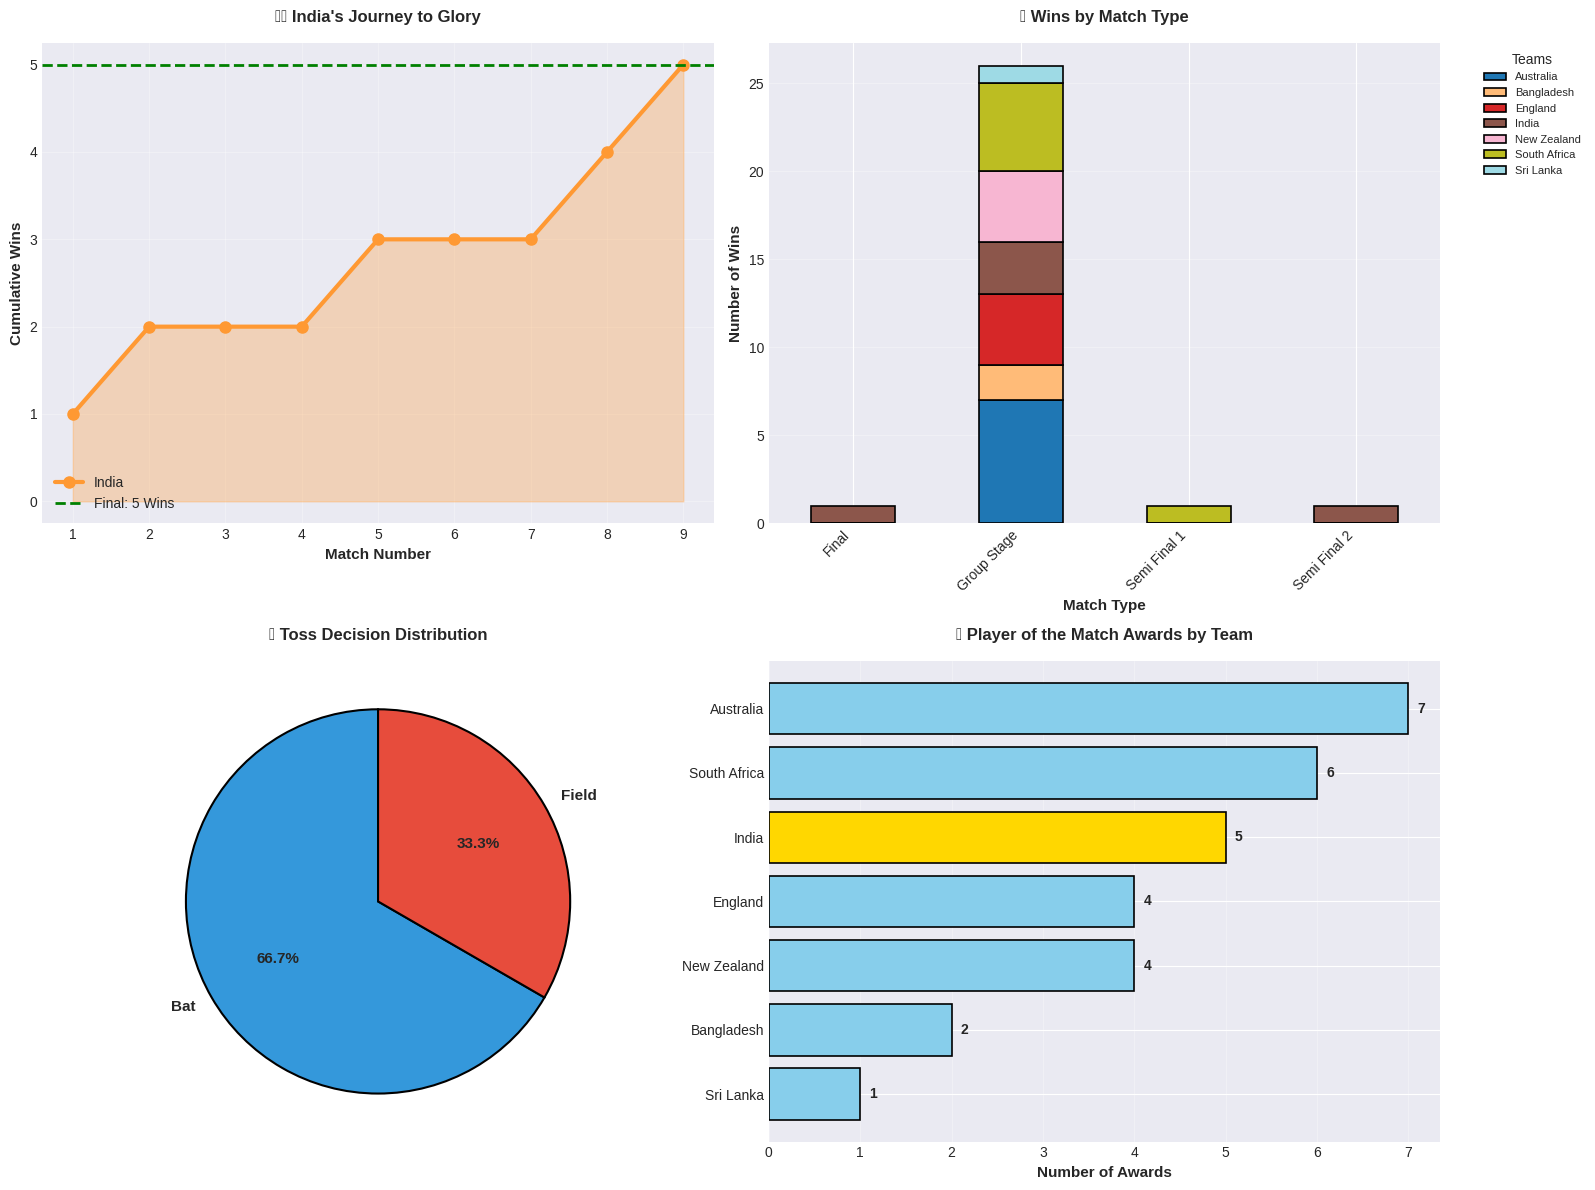

In [14]:
# Create a visual summary of records
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Record 1: Tournament progression - India's journey
india_matches = matches[(matches['team1'] == 'India') | (matches['team2'] == 'India')].copy()
india_matches['india_won'] = (india_matches['winner'] == 'India').astype(int)
india_matches['match_num'] = range(1, len(india_matches) + 1)
india_matches['cumulative_wins'] = india_matches['india_won'].cumsum()

axes[0, 0].plot(india_matches['match_num'], india_matches['cumulative_wins'], 
               marker='o', markersize=8, linewidth=3, color='#FF9933', label='India')
axes[0, 0].fill_between(india_matches['match_num'], india_matches['cumulative_wins'], alpha=0.3, color='#FF9933')
axes[0, 0].set_xlabel('Match Number', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Cumulative Wins', fontsize=11, fontweight='bold')
axes[0, 0].set_title("🇮🇳 India's Journey to Glory", fontsize=12, fontweight='bold', pad=15)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=india_matches['cumulative_wins'].iloc[-1], color='green', linestyle='--', 
                  linewidth=2, label=f'Final: {india_matches["cumulative_wins"].iloc[-1]} Wins')
axes[0, 0].legend()

# Record 2: Match results by type
match_type_wins = matches[matches['winner'].notna() & (matches['winner'] != 'No result')].groupby('match_type')['winner'].value_counts().unstack(fill_value=0)
if len(match_type_wins) > 0:
    match_type_wins.plot(kind='bar', ax=axes[0, 1], stacked=True, colormap='tab20', edgecolor='black', linewidth=1.2)
    axes[0, 1].set_xlabel('Match Type', fontsize=11, fontweight='bold')
    axes[0, 1].set_ylabel('Number of Wins', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('🏆 Wins by Match Type', fontsize=12, fontweight='bold', pad=15)
    axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
    axes[0, 1].legend(title='Teams', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0, 1].grid(axis='y', alpha=0.3)

# Record 3: Toss decision impact
toss_decisions = matches[matches['toss_decision'].notna()]['toss_decision'].value_counts()
colors_toss = ['#3498db', '#e74c3c']
axes[1, 0].pie(toss_decisions.values, labels=toss_decisions.index, autopct='%1.1f%%',
              startangle=90, colors=colors_toss, textprops={'fontsize': 11, 'fontweight': 'bold'},
              wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1, 0].set_title('🪙 Toss Decision Distribution', fontsize=12, fontweight='bold', pad=15)

# Record 4: Player of the Match awards by team
potm_by_team = matches[matches['player_of_match'].notna()].copy()
# Extract team from player_of_match by matching with other data
team_potm_count = {}
for team in points['team']:
    count = len(potm_by_team[(potm_by_team['winner'] == team)])
    if count > 0:
        team_potm_count[team] = count

if team_potm_count:
    teams_sorted = sorted(team_potm_count.items(), key=lambda x: x[1], reverse=True)
    teams, counts = zip(*teams_sorted)
    colors_potm = ['gold' if t == 'India' else 'skyblue' for t in teams]
    axes[1, 1].barh(teams, counts, color=colors_potm, edgecolor='black', linewidth=1.2)
    axes[1, 1].set_xlabel('Number of Awards', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('⭐ Player of the Match Awards by Team', fontsize=12, fontweight='bold', pad=15)
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(axis='x', alpha=0.3)
    for i, (team, count) in enumerate(zip(teams, counts)):
        axes[1, 1].text(count + 0.1, i, str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
# 🔍 Part 6: Advanced Analysis & Insights

## 📊 Correlation Analysis

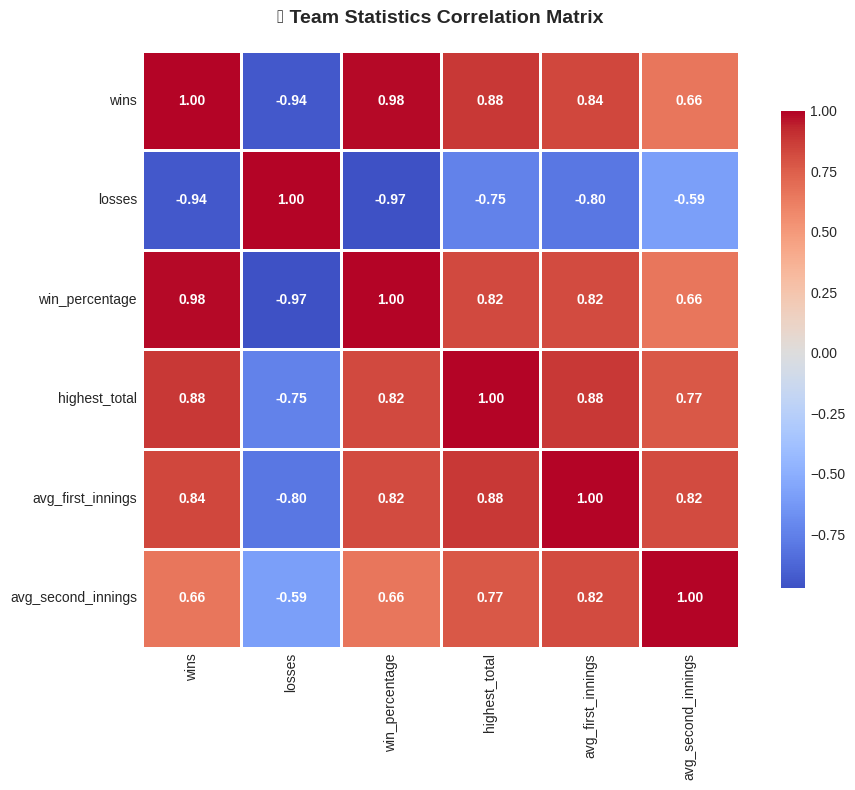


📊 Key Correlations:
   • Win % and Highest Total: 0.82
   • Wins and Average 1st Innings: 0.84


In [15]:
# Create correlation matrix for team statistics
numeric_cols = ['wins', 'losses', 'win_percentage', 'highest_total', 'avg_first_innings', 'avg_second_innings']
correlation_data = team_stats[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, linewidths=2, cbar_kws={"shrink": 0.8},
           annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title('🔥 Team Statistics Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Key Correlations:")
print(f"   • Win % and Highest Total: {correlation_data.loc['win_percentage', 'highest_total']:.2f}")
print(f"   • Wins and Average 1st Innings: {correlation_data.loc['wins', 'avg_first_innings']:.2f}")

## 🎯 Match Outcomes Analysis

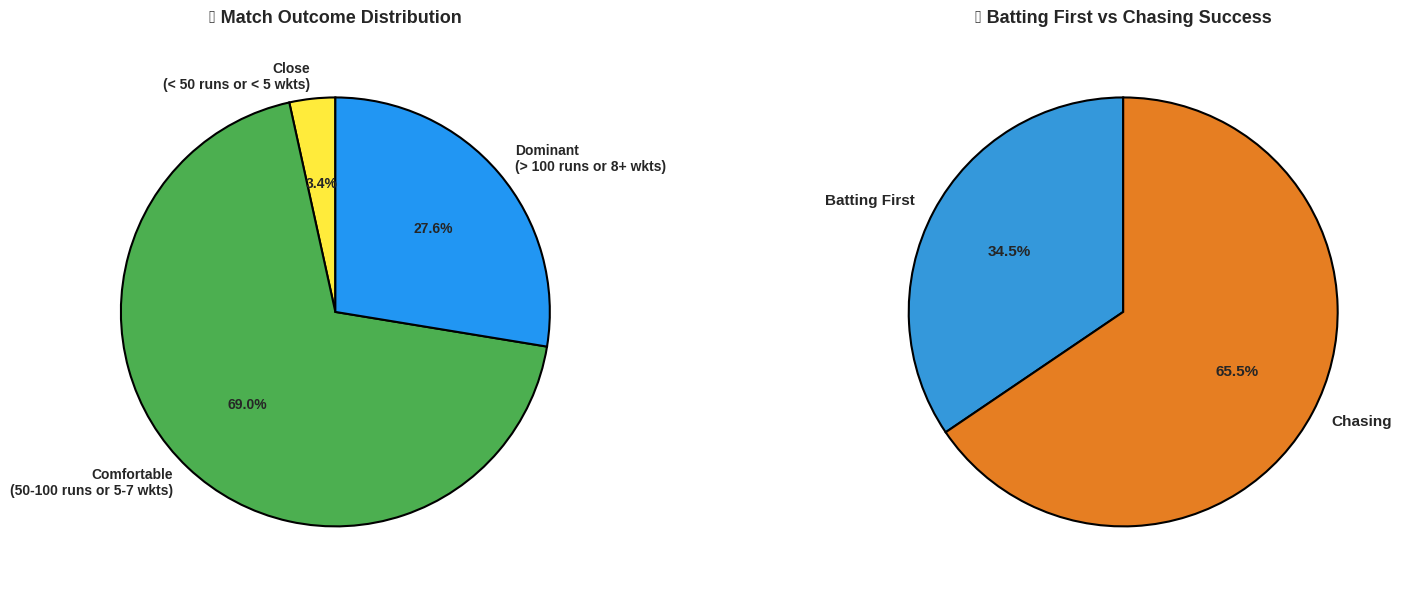


📈 Match Outcome Insights:
   • Teams batting first won: 10 matches (34.5%)
   • Teams chasing won: 19 matches (65.5%)


In [16]:
# Analyze margin of victories
completed_matches = matches[matches['winner'].notna() & (matches['winner'] != 'No result')].copy()

# Categorize margins
run_margins = completed_matches[completed_matches['margin'].str.contains('run', na=False)]
wicket_margins = completed_matches[completed_matches['margin'].str.contains('wicket', na=False)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Close vs comfortable wins
win_types = {
    'Close\n(< 50 runs or < 5 wkts)': 0,
    'Comfortable\n(50-100 runs or 5-7 wkts)': 0,
    'Dominant\n(> 100 runs or 8+ wkts)': 0
}

for margin in completed_matches['margin']:
    if 'run' in str(margin):
        try:
            runs = int(str(margin).split()[0])
            if runs < 50:
                win_types['Close\n(< 50 runs or < 5 wkts)'] += 1
            elif runs < 100:
                win_types['Comfortable\n(50-100 runs or 5-7 wkts)'] += 1
            else:
                win_types['Dominant\n(> 100 runs or 8+ wkts)'] += 1
        except:
            pass
    elif 'wicket' in str(margin):
        try:
            wickets = int(str(margin).split()[0])
            if wickets < 5:
                win_types['Close\n(< 50 runs or < 5 wkts)'] += 1
            elif wickets < 8:
                win_types['Comfortable\n(50-100 runs or 5-7 wkts)'] += 1
            else:
                win_types['Dominant\n(> 100 runs or 8+ wkts)'] += 1
        except:
            pass

colors_win = ['#ffeb3b', '#4caf50', '#2196f3']
axes[0].pie(win_types.values(), labels=win_types.keys(), autopct='%1.1f%%',
           startangle=90, colors=colors_win, textprops={'fontsize': 10, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[0].set_title('🎯 Match Outcome Distribution', fontsize=13, fontweight='bold', pad=15)

# Plot 2: Winners by batting first vs chasing
bat_first_wins = 0
chase_wins = 0
for _, match in completed_matches.iterrows():
    if match['winner'] == match['team1']:
        bat_first_wins += 1
    else:
        chase_wins += 1

battle_data = {'Batting First': bat_first_wins, 'Chasing': chase_wins}
colors_battle = ['#3498db', '#e67e22']
axes[1].pie(battle_data.values(), labels=battle_data.keys(), autopct='%1.1f%%',
           startangle=90, colors=colors_battle, textprops={'fontsize': 11, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('🏏 Batting First vs Chasing Success', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(f"\n📈 Match Outcome Insights:")
print(f"   • Teams batting first won: {bat_first_wins} matches ({bat_first_wins/len(completed_matches)*100:.1f}%)")
print(f"   • Teams chasing won: {chase_wins} matches ({chase_wins/len(completed_matches)*100:.1f}%)")

---
# 🎊 Part 7: Final Summary & Key Takeaways

## 🏆 Tournament Summary

In [17]:
print("\n" + "="*80)
print("🏆 ICC WOMEN'S CRICKET WORLD CUP 2025 - FINAL SUMMARY")
print("="*80)

print("\n🎉 CHAMPION: INDIA WOMEN 🇮🇳")
print("   • India's first ever ODI World Cup title!")
print("   • Defeated South Africa by 52 runs in the final")
print("   • Historic achievement for Indian women's cricket")

print("\n⭐ TOP PERFORMERS:")
print(f"   • Highest Run Scorer: {top_scorers.iloc[0]['player_name']} - {top_scorers.iloc[0]['runs']} runs")
print(f"   • Most Wickets: {top_bowlers.iloc[0]['player_name']} - {top_bowlers.iloc[0]['wickets']} wickets")
print(f"   • Player of Tournament: Deepti Sharma (India)")
print(f"   • Player of Final: Shafali Verma (India)")

print("\n📊 TOURNAMENT STATISTICS:")
print(f"   • Total Matches: {len(matches)}")
print(f"   • Participating Teams: {len(points)}")
print(f"   • Highest Team Total: {team_stats['highest_total'].max()}")
print(f"   • Lowest Team Total: {team_stats['lowest_total'].min()}")
print(f"   • Average Runs Per Match: {team_stats['avg_first_innings'].mean():.1f}")

print("\n🌟 KEY HIGHLIGHTS:")
print("   • First World Cup final without Australia or England")
print("   • Highest successful chase: 336/4 by India vs Australia")
print("   • Laura Wolvaardt's 571 runs - New World Cup record")
print("   • Record prize money: $4.48 million for winners")
print("   • Total prize pool: $13.88 million (297% increase from 2022)")

print("\n🎯 TOURNAMENT RECORDS:")
records_summary = awards[awards['award_category'].str.contains('Highest|Best|Most')]
for _, record in records_summary.iterrows():
    print(f"   • {record['award_category']}: {record['recipient']} ({record['team']})")

print("\n" + "="*80)
print("🙌 CONGRATULATIONS TO ALL TEAMS AND PLAYERS!")
print("   Thank you for an incredible tournament!")
print("="*80 + "\n")


🏆 ICC WOMEN'S CRICKET WORLD CUP 2025 - FINAL SUMMARY

🎉 CHAMPION: INDIA WOMEN 🇮🇳
   • India's first ever ODI World Cup title!
   • Defeated South Africa by 52 runs in the final
   • Historic achievement for Indian women's cricket

⭐ TOP PERFORMERS:
   • Highest Run Scorer: Laura Wolvaardt - 571 runs
   • Most Wickets: Deepti Sharma - 22 wickets
   • Player of Tournament: Deepti Sharma (India)
   • Player of Final: Shafali Verma (India)

📊 TOURNAMENT STATISTICS:
   • Total Matches: 31
   • Participating Teams: 8
   • Highest Team Total: 333
   • Lowest Team Total: 69
   • Average Runs Per Match: 198.3

🌟 KEY HIGHLIGHTS:
   • First World Cup final without Australia or England
   • Highest successful chase: 336/4 by India vs Australia
   • Laura Wolvaardt's 571 runs - New World Cup record
   • Record prize money: $4.48 million for winners
   • Total prize pool: $13.88 million (297% increase from 2022)

🎯 TOURNAMENT RECORDS:
   • Most Runs: Laura Wolvaardt (South Africa)
   • Most Wickets

## 💡 Key Insights & Observations

In [18]:
print("\n🔍 KEY INSIGHTS FROM THE TOURNAMENT:")
print("="*80)

print("\n1. 🏏 BATTING TRENDS:")
print(f"   • Average first innings score: {team_stats['avg_first_innings'].mean():.1f}")
print(f"   • Average chase score: {team_stats['avg_second_innings'].mean():.1f}")
print(f"   • Teams batting first scored {((team_stats['avg_first_innings'].mean() - team_stats['avg_second_innings'].mean()) / team_stats['avg_first_innings'].mean() * 100):.1f}% more on average")

print("\n2. 🎯 TOSS IMPACT:")
print(f"   • Toss win to match win conversion: {toss_win_rate:.1f}%")
if toss_win_rate > 55:
    print("   • Winning toss had a significant advantage")
elif toss_win_rate < 45:
    print("   • Toss result had minimal impact on match outcomes")
else:
    print("   • Toss impact was neutral")

print("\n3. 🏟️ VENUE CHARACTERISTICS:")
best_batting = venue_stats.loc[venue_stats['avg_first_innings'].idxmax()]
print(f"   • Best batting venue: {best_batting['venue']} (Avg: {best_batting['avg_first_innings']:.1f})")
best_bowling = venue_stats.loc[venue_stats['avg_first_innings'].idxmin()]
print(f"   • Most bowling-friendly: {best_bowling['venue']} (Avg: {best_bowling['avg_first_innings']:.1f})")

print("\n4. 🌟 STANDOUT PERFORMANCES:")
print(f"   • Laura Wolvaardt's 571 runs broke the previous World Cup record")
print(f"   • Deepti Sharma's all-round excellence (215 runs + 22 wickets)")
print(f"   • Alana King's historic 7/20 - Best bowling in Women's World Cup")
print(f"   • India's 336/4 chase - Highest successful chase in tournament history")

print("\n5. 🏆 TEAM DYNAMICS:")
print(f"   • India won despite losing 3 group matches - showing resilience")
print(f"   • South Africa reached their maiden final")
print(f"   • Australia won 15 consecutive World Cup matches before semi-final loss")
print(f"   • New champion crowned for first time since 2017")

print("\n" + "="*80)


🔍 KEY INSIGHTS FROM THE TOURNAMENT:

1. 🏏 BATTING TRENDS:
   • Average first innings score: 198.3
   • Average chase score: 186.6
   • Teams batting first scored 5.9% more on average

2. 🎯 TOSS IMPACT:
   • Toss win to match win conversion: 62.1%
   • Winning toss had a significant advantage

3. 🏟️ VENUE CHARACTERISTICS:
   • Best batting venue: Navi Mumbai (Avg: 283.8)
   • Most bowling-friendly: Colombo (Avg: 172.4)

4. 🌟 STANDOUT PERFORMANCES:
   • Laura Wolvaardt's 571 runs broke the previous World Cup record
   • Deepti Sharma's all-round excellence (215 runs + 22 wickets)
   • Alana King's historic 7/20 - Best bowling in Women's World Cup
   • India's 336/4 chase - Highest successful chase in tournament history

5. 🏆 TEAM DYNAMICS:
   • India won despite losing 3 group matches - showing resilience
   • South Africa reached their maiden final
   • Australia won 15 consecutive World Cup matches before semi-final loss
   • New champion crowned for first time since 2017



---

## 📝 Conclusion

The ICC Women's Cricket World Cup 2025 will be remembered as a historic tournament that:

- 🏆 **Crowned India as first-time champions** - A landmark achievement for Indian women's cricket
- 🌟 **Showcased exceptional talent** - From Laura Wolvaardt's record-breaking run spree to Deepti Sharma's all-round brilliance
- 💪 **Demonstrated competitive balance** - With South Africa reaching their maiden final and multiple close contests
- 💰 **Achieved gender parity** - Record prize money exceeding the men's 2023 World Cup
- 🎉 **Created unforgettable moments** - From thrilling chases to dominant performances

This analysis covered comprehensive statistics across matches, players, teams, and venues, providing insights into one of the most exciting Women's World Cups ever played!

---

### 🙏 Thank You!

**If you found this analysis helpful:**
- ⭐ Please upvote this notebook
- 💬 Share your insights in the comments
- 🔗 Share with the cricket analytics community

**Dataset Source:** https://www.kaggle.com/datasets/ibrahimqasimi/feaers-report-id
**Connect with me for more cricket analytics!**

---

### 📊 Future Analysis Ideas:
- Player form throughout tournament stages
- Impact of powerplay performances on final scores
- Death overs analysis (46-50)
- Partnership analysis
- Match prediction models
- Player performance vs different oppositions

**Stay tuned for more cricket data science content!** 🏏📈